# House Price Prediction

Dataset: House Price by Juhi Bhojani - https://www.kaggle.com/datasets/juhibhojani/house-price

## 2.1 Load & Inspect

In [2]:
import pandas as pd

df = pd.read_csv("data/house_prices.csv")
df.shape

(187531, 21)

In [3]:
df.head()

,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,...,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,...,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,...,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  str    
 2   Description        184508 non-null  str    
 3   Amount(in rupees)  187531 non-null  str    
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  str    
 6   Carpet Area        106858 non-null  str    
 7   Status             186916 non-null  str    
 8   Floor              180454 non-null  str    
 9   Transaction        187448 non-null  str    
 10  Furnishing         184634 non-null  str    
 11  facing             117298 non-null  str    
 12  overlooking        106095 non-null  str    
 13  Society            77853 non-null   str    
 14  Bathroom           186703 non-null  str    
 15  Balcony            138596 non-null  str    
 16  Car Parking  

In [5]:
df.describe()

,Index,Price (in rupees),Dimensions,Plot Area
count,187531.000000,1.698660e+05,0.0,0.0
mean,93765.000000,7.583772e+03,NaN,NaN
std,54135.681003,2.724171e+04,NaN,NaN
min,0.000000,0.000000e+00,NaN,NaN
25%,46882.500000,4.297000e+03,NaN,NaN
50%,93765.000000,6.034000e+03,NaN,NaN
75%,140647.500000,9.450000e+03,NaN,NaN
max,187530.000000,6.700000e+06,NaN,NaN


In [6]:
df.isna().mean().sort_values(ascending=False)

Plot Area            1.000000
Dimensions           1.000000
Society              0.584853
Super Area           0.574225
Car Parking          0.551146
overlooking          0.434254
Carpet Area          0.430185
facing               0.374514
Ownership            0.349366
Balcony              0.260944
Price (in rupees)    0.094198
Floor                0.037738
Description          0.016120
Furnishing           0.015448
Bathroom             0.004415
Status               0.003279
Transaction          0.000443
Amount(in rupees)    0.000000
Title                0.000000
Index                0.000000
location             0.000000
dtype: float64

**How many rows**?
187,531 rows, 21 columns.

---



Which columns are numeric vs text?

**Numeric (int64/float64):** Index, Price (in rupees), Dimensions, Plot Area                     
**Text (object):** Title, Description, Amount(in
rupees), location, Carpet Area, Status, Floor, Transaction, Furnishing, facing, overlooking, Society, Bathroom, Balcony, Car Parking, Ownership, Super Area


---
**Which columns have the most missing values?**

Plot Area and Dimensions are 100% missing (all NaN). After those, Society (58%), Super Area (57%), Car Parking (55%), overlooking (43%), and Carpet Area (43%) also have a lot of missing values

## 2.2 EDA

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
def parse_amount(x):
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    try:
        if "lac" in x:
            return float(x.replace("lac", "").strip()) * 1e5
        if "cr" in x:
            return float(x.replace("cr", "").strip()) * 1e7
        return float(x.replace(",", ""))
    except ValueError:
        return None

df["price_clean"] = df["Amount(in rupees)"].apply(parse_amount)
df_eda = df.dropna(subset=["price_clean"]).copy()
df_eda.shape

(177847, 22)

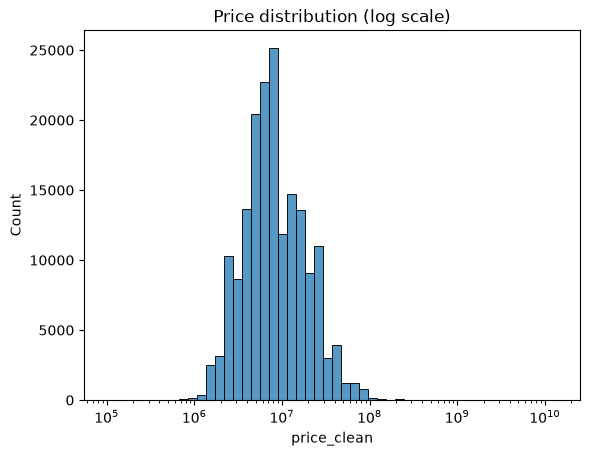

In [9]:
sns.histplot(df_eda["price_clean"], log_scale=True, bins=50)
plt.title("Price distribution (log scale)")
plt.show()

On a log scale the price distribution looks roughly bell-shaped, peaking around 10^6-10^7. There's still a long tail stretching out to 10^9-10^10, so a handful of listings are priced far above the rest.

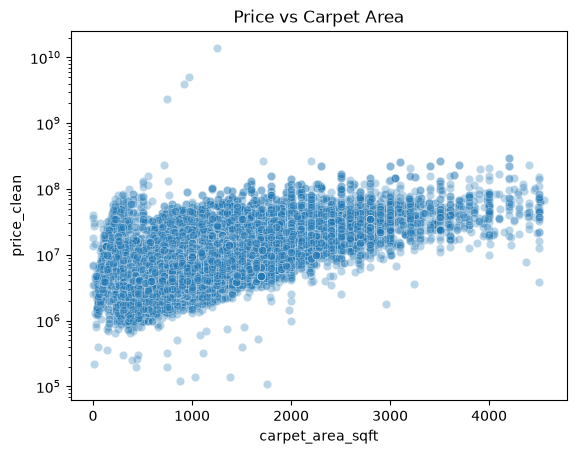

In [10]:
def parse_area(x):
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    try:
        num = float("".join(c for c in x if c.isdigit() or c == "."))
    except ValueError:
        return None
    if "sqm" in x:
        return num * 10.764
    return num

df_eda["carpet_area_sqft"] = df_eda["Carpet Area"].apply(parse_area)

sample = df_eda.dropna(subset=["carpet_area_sqft"])
sample = sample[sample["carpet_area_sqft"] < sample["carpet_area_sqft"].quantile(0.99)]

sns.scatterplot(data=sample, x="carpet_area_sqft", y="price_clean", alpha=0.3)
plt.yscale("log")
plt.title("Price vs Carpet Area")
plt.show()

Most listings cluster under 1000 sqft with prices between 10^6 and 10^8. There's a general upward trend, but the spread is wide, and a few outliers combine large area with very high prices, so area alone won't explain price well.

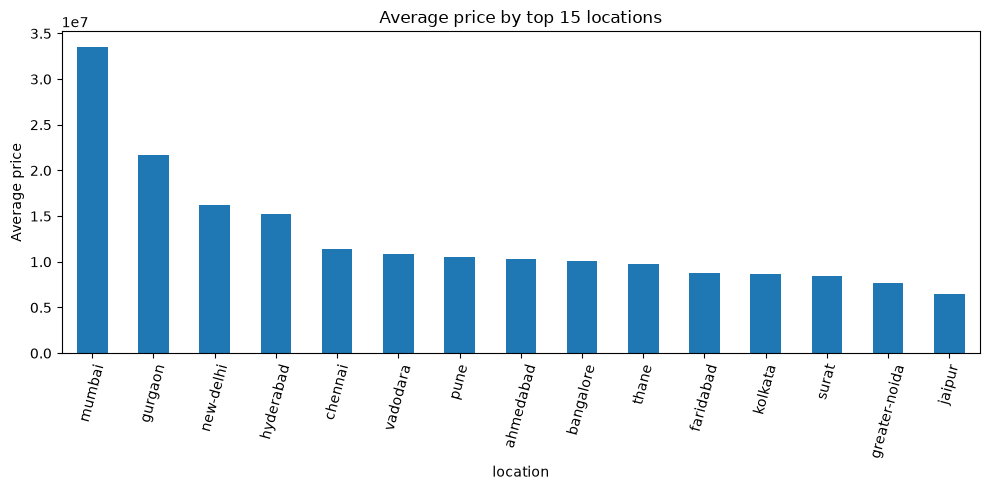

In [11]:
top_locations = df_eda["location"].value_counts().head(15).index
avg_price = (df_eda[df_eda["location"].isin(top_locations)]
             .groupby("location")["price_clean"].mean()
             .sort_values(ascending=False))

avg_price.plot(kind="bar", figsize=(10, 5))
plt.title("Average price by top 15 locations")
plt.ylabel("Average price")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()

Mumbai stands out with an average price roughly double Gurgaon, the next highest. After that the top locations (New-Delhi, Hyderabad, Chennai) drop off gradually, with the lowest of the top 15 (Jaipur) sitting well under a third of Mumbai's average.

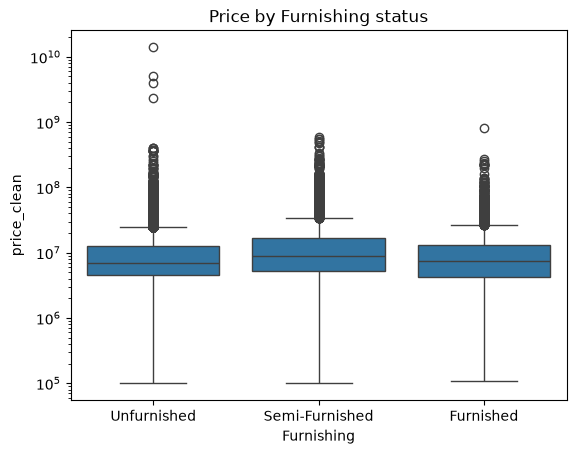

In [12]:
sns.boxplot(data=df_eda, x="Furnishing", y="price_clean")
plt.yscale("log")
plt.title("Price by Furnishing status")
plt.show()

Semi-Furnished has the highest median price here, slightly above Furnished, and both are above Unfurnished. All three groups have a long tail of high-priced outliers.

## 2.3 Cleaning & Feature Engineering

In [13]:
df = pd.read_csv("data/house_prices.csv")
df.shape

(187531, 21)

In [14]:
df["price_clean"] = df["Amount(in rupees)"].apply(parse_amount)
df = df.dropna(subset=["price_clean"])
df.shape

(177847, 22)

In [15]:
df["carpet_area_sqft"] = df["Carpet Area"].apply(parse_area)
df["super_area_sqft"] = df["Super Area"].apply(parse_area)
df["carpet_area_sqft"] = df["carpet_area_sqft"].fillna(df["super_area_sqft"])

In [16]:
def parse_floor(x):
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    part = x.split("out of")[0].strip()
    if "ground" in part:
        return 0
    if "basement" in part:
        return -1
    try:
        return int("".join(c for c in part if c.isdigit()))
    except ValueError:
        return None

df["floor_num"] = df["Floor"].apply(parse_floor)

In [17]:
for col in ["Bathroom", "Balcony", "Car Parking"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["bathroom"] = df["Bathroom"].fillna(df["Bathroom"].median())
df["balcony"] = df["Balcony"].fillna(0)
df["car_parking"] = df["Car Parking"].fillna(0)

In [18]:
TOP_N = 50
top_locations = df["location"].value_counts().head(TOP_N).index
df["location_grouped"] = df["location"].where(df["location"].isin(top_locations), "other")

In [19]:
df = df.drop(columns=[c for c in ["Index", "Title", "Description", "Dimensions"] if c in df.columns])

In [20]:
df = df.dropna(subset=["carpet_area_sqft"])
df = df[df["carpet_area_sqft"] > 0]

df["price_per_sqft"] = df["price_clean"] / df["carpet_area_sqft"]
low, high = df["price_per_sqft"].quantile([0.01, 0.99])
df = df[df["price_per_sqft"].between(low, high)]
df = df.drop(columns=["price_per_sqft"])

df.shape

(174471, 25)

## 2.4 Pipeline & Train

In [21]:
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

In [22]:
numeric_features = ["carpet_area_sqft", "floor_num", "bathroom", "balcony"]
categorical_features = ["location_grouped", "Furnishing", "Transaction", "Ownership", "facing"]

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler())
    ]), numeric_features),
    ("cat", Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]), categorical_features),
])

X = df[numeric_features + categorical_features]
y = df["price_clean"]
y_log = np.log1p(y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
_, _, y_train_log, y_test_log = train_test_split(X, y_log, test_size=0.2, random_state=42)

In [23]:
models = {
    "LinearRegression": LinearRegression(),
    "RandomForest": RandomForestRegressor(
        n_estimators=100, max_depth=18, min_samples_leaf=3,
        random_state=42, n_jobs=-1
    ),
    "GradientBoosting": GradientBoostingRegressor(random_state=42),
}

results = []
fitted_models = {}

for name, reg in models.items():
    pipe = Pipeline([("prep", preprocessor), ("reg", reg)])
    pipe.fit(X_train, y_train_log)
    pred = np.expm1(pipe.predict(X_test))

    results.append({
        "model": name,
        "MAE": mean_absolute_error(y_test, pred),
        "RMSE": root_mean_squared_error(y_test, pred),
        "R2": r2_score(y_test, pred),
    })
    fitted_models[name] = pipe

results_df = pd.DataFrame(results).sort_values("R2", ascending=False)
results_df

,model,MAE,RMSE,R2
1,RandomForest,1.138027e+06,5.628171e+06,0.830360
2,GradientBoosting,2.987291e+06,7.411947e+06,0.705790
0,LinearRegression,1.628460e+07,1.241205e+09,-8249.491453


## 2.5 Evaluate

In [26]:
best_model_name = results_df.iloc[0]["model"]
best_pipe = fitted_models[best_model_name]
best_model_name

'RandomForest'

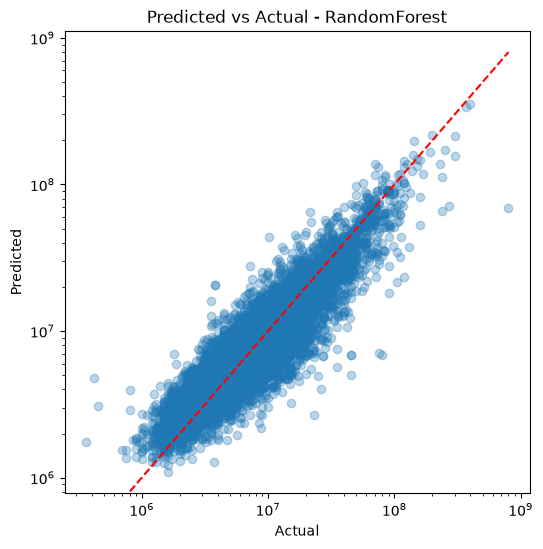

In [25]:
pred = np.expm1(best_pipe.predict(X_test))

plt.figure(figsize=(6, 6))
plt.scatter(y_test, pred, alpha=0.3)
max_val = max(y_test.max(), pred.max())
plt.plot([0, max_val], [0, max_val], "r--")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title(f"Predicted vs Actual - {best_model_name}")
plt.show()

In [49]:
cv_scores = cross_val_score(best_pipe, X, y_log, cv=5, scoring="r2")
cv_scores, cv_scores.mean()

(array([0.77139212, 0.45746569, 0.93001337, 0.46104373, 0.42302866]),
 np.float64(0.6085887123313063))

RandomForest came out on top with the best R2/MAE/RMSE on the test set. Makes sense since it can pick up on the non-linear relationship between location/area and price better than plain linear regression.

## 2.6 Export the Model

In [27]:
import joblib
import json
import sklearn

joblib.dump(best_pipe, "house_price.pkl", compress=3)

loaded = joblib.load("house_price.pkl")
sample = X_test.iloc[[0]]
print("Reloaded prediction:", np.expm1(loaded.predict(sample)))

json.dump(sorted(df["location_grouped"].unique().tolist()), open("locations.json", "w"))

print("sklearn version:", sklearn.__version__)

Reloaded prediction: [6991706.59836445]
sklearn version: 1.9.0


In [28]:
for col in ["Furnishing", "Transaction", "Ownership", "facing"]:
    print(col, ":", sorted(df[col].dropna().unique().tolist()))

Furnishing : ['Furnished', 'Semi-Furnished', 'Unfurnished']
Transaction : ['New Property', 'Other', 'Rent/Lease', 'Resale']
Ownership : ['Co-operative Society', 'Freehold', 'Leasehold', 'Power Of Attorney']
facing : ['East', 'North', 'North - East', 'North - West', 'South', 'South - East', 'South -West', 'West']


In [29]:
results_df

,model,MAE,RMSE,R2
1,RandomForest,1.138027e+06,5.628171e+06,0.830360
2,GradientBoosting,2.987291e+06,7.411947e+06,0.705790
0,LinearRegression,1.628460e+07,1.241205e+09,-8249.491453


Model was trained on log1p(price), so the backend needs to apply np.expm1() to predict() output before returning the price.